# 2026 Mobile DAU — June Forecast vs April Forecast

Recreates the chart comparing the April-vintage forecast ("Prior") against the June-vintage draft ("Current"), with and without Iran.

Source data: `~/Downloads/june_mobile_plot_series.adj-h.csv` (already 28-day MA).

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.dates as mdates
import pandas as pd

CSV_PATH = Path.home() / "Downloads" / "june_mobile_plot_series.adj-h.csv"

In [2]:
df = pd.read_csv(CSV_PATH, parse_dates=["date"])
df = df[df["date"].dt.year == 2026].set_index("date").sort_index()
df.head()

,actuals_all,actuals_no_iran,april_plus_iran,april_no_iran,june_draft_plus_iran,june_draft_iran
date,,,,,,
2026-01-01,1.547388e+07,1.494799e+07,1.547388e+07,1.494799e+07,1.547388e+07,1.494799e+07
2026-01-02,1.546053e+07,1.493562e+07,1.546053e+07,1.493562e+07,1.546053e+07,1.493562e+07
2026-01-03,1.545777e+07,1.493597e+07,1.545777e+07,1.493597e+07,1.545777e+07,1.493597e+07
2026-01-04,1.546118e+07,1.493969e+07,1.546118e+07,1.493969e+07,1.546118e+07,1.493969e+07
2026-01-05,1.546057e+07,1.493924e+07,1.546057e+07,1.493924e+07,1.546057e+07,1.493924e+07


In [3]:
# The April forecast is plotted across the whole year (backtest view).
# The June "current" forecast is only plotted from the day after the last actual,
# i.e. from the forecast cutoff onward.
last_actual = df["actuals_all"].dropna().index.max()
current_start = last_actual
current_mask = df.index >= current_start
last_actual

Timestamp('2026-05-13 00:00:00')

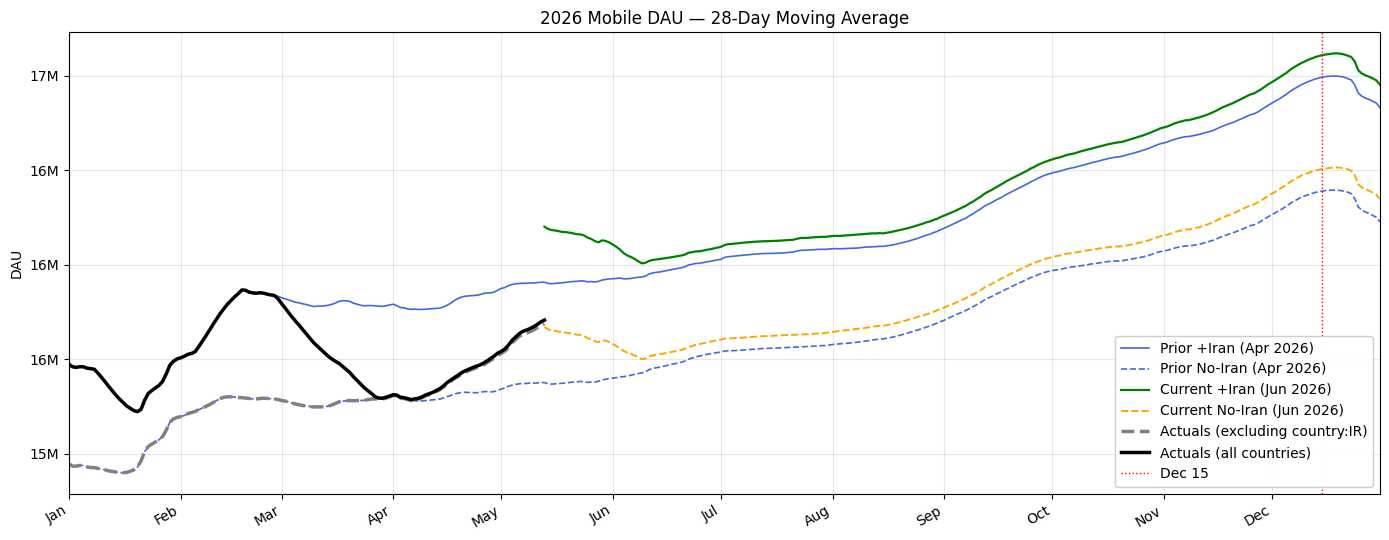

In [4]:
fig, ax = plt.subplots(figsize=(14, 5.5))

# Prior (April) forecast — full year
ax.plot(df.index, df["april_plus_iran"], color="royalblue", lw=1.2,
        label="Prior +Iran (Apr 2026)")
ax.plot(df.index, df["april_no_iran"], color="royalblue", lw=1.2, ls="--",
        label="Prior No-Iran (Apr 2026)")

# Current (June) forecast — from forecast cutoff onward
ax.plot(df.index[current_mask], df.loc[current_mask, "june_draft_plus_iran"],
        color="green", lw=1.6, label="Current +Iran (Jun 2026)")
ax.plot(df.index[current_mask], df.loc[current_mask, "june_draft_iran"],
        color="orange", lw=1.4, ls="--", label="Current No-Iran (Jun 2026)")

# Actuals on top
ax.plot(df.index, df["actuals_no_iran"], color="gray", lw=2.5, ls="--",
        label="Actuals (excluding country:IR)")
ax.plot(df.index, df["actuals_all"], color="black", lw=2.5,
        label="Actuals (all countries)")

# Dec 15 marker
ax.axvline(pd.Timestamp("2026-12-15"), color="red", ls=":", lw=1, label="Dec 15")

ax.set_title("2026 Mobile DAU \u2014 28-Day Moving Average")
ax.set_ylabel("DAU")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.0f}M"))
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
ax.set_xlim(df.index.min(), df.index.max())
ax.grid(True, alpha=0.3)
ax.legend(loc="lower right", framealpha=0.95)
plt.setp(ax.get_xticklabels(), rotation=30, ha="right")
plt.tight_layout()
plt.show()

## Delta: Actuals (excl. IR) vs Prior No-Iran Forecast (Apr 6 — today)

Compute the delta on the no-Iran basis to get a clean trend (Iran's traffic is volatile / partially blocked). We'll later add this projected delta on top of the +Iran prior to project all-countries DAU.

Delta = `actuals_no_iran − april_no_iran`. Positive = actuals above forecast.

In [5]:
TODAY = pd.Timestamp("2026-05-15")
DELTA_START = pd.Timestamp("2026-04-06")
window = df.loc[DELTA_START:TODAY].copy()
window["delta"] = window["actuals_no_iran"] - window["april_no_iran"]
window["delta_pct"] = window["delta"] / window["april_no_iran"] * 100
delta = window[["actuals_no_iran", "april_no_iran", "delta", "delta_pct"]].dropna()
print(f"Window: {delta.index.min().date()} → {delta.index.max().date()}  ({len(delta)} days)")
print(f"Mean delta:   {delta['delta'].mean():,.0f} ({delta['delta_pct'].mean():+.2f}%)")
print(f"Latest delta: {delta['delta'].iloc[-1]:,.0f} ({delta['delta_pct'].iloc[-1]:+.2f}%)")
delta.tail()

Window: 2026-04-06 → 2026-05-13  (38 days)
Mean delta:   142,016 (+0.93%)
Latest delta: 310,194 (+2.02%)


,actuals_no_iran,april_no_iran,delta,delta_pct
date,,,,
2026-05-09,1.564645e+07,1.537477e+07,271683.034777,1.767071
2026-05-10,1.565534e+07,1.537437e+07,280974.418692,1.827551
2026-05-11,1.566664e+07,1.537542e+07,291223.257081,1.894084
2026-05-12,1.567905e+07,1.537731e+07,301737.992636,1.962229
2026-05-13,1.568775e+07,1.537755e+07,310194.212228,2.017189


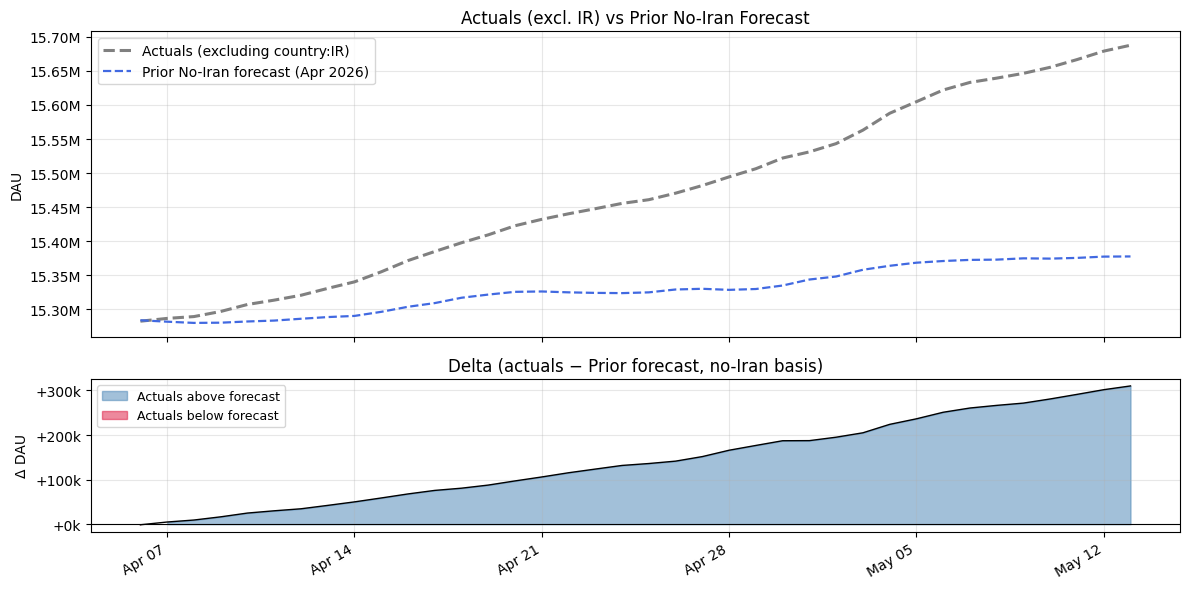

In [6]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6), sharex=True,
                                gridspec_kw={"height_ratios": [2, 1]})

ax1.plot(delta.index, delta["actuals_no_iran"], color="gray", lw=2.2, ls="--",
         label="Actuals (excluding country:IR)")
ax1.plot(delta.index, delta["april_no_iran"], color="royalblue", lw=1.6, ls="--",
         label="Prior No-Iran forecast (Apr 2026)")
ax1.set_ylabel("DAU")
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.2f}M"))
ax1.legend(loc="upper left")
ax1.grid(True, alpha=0.3)
ax1.set_title("Actuals (excl. IR) vs Prior No-Iran Forecast")

ax2.axhline(0, color="black", lw=0.8)
ax2.fill_between(delta.index, 0, delta["delta"],
                 where=delta["delta"] >= 0, color="steelblue", alpha=0.5, label="Actuals above forecast")
ax2.fill_between(delta.index, 0, delta["delta"],
                 where=delta["delta"] < 0, color="crimson", alpha=0.5, label="Actuals below forecast")
ax2.plot(delta.index, delta["delta"], color="black", lw=1)
ax2.set_ylabel("Δ DAU")
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e3:+.0f}k"))
ax2.xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
ax2.grid(True, alpha=0.3)
ax2.legend(loc="upper left", fontsize=9)
ax2.set_title("Delta (actuals − Prior forecast, no-Iran basis)")
plt.setp(ax2.get_xticklabels(), rotation=30, ha="right")
plt.tight_layout()
plt.show()

## Project delta trend through Dec 15

Fit a linear regression to the (actuals − Prior) delta over Apr 1 → May 13, then extrapolate the trend through Dec 15. Add the projected delta to the April-vintage forecast to get an "if-the-current-trend-continues" trajectory, and compare it to the June draft.

In [7]:
import numpy as np

PROJ_END = pd.Timestamp("2026-12-15")
fit_start = pd.Timestamp("2026-04-06")
fit_end = delta.index.max()  # 2026-05-13
HALF_SLOPE_FROM = pd.Timestamp("2026-07-01")

# Linear fit on the no-Iran delta. x = days since fit_start.
x_fit = (delta.index - fit_start).days.to_numpy(dtype=float)
y_fit = delta["delta"].to_numpy()
slope, intercept = np.polyfit(x_fit, y_fit, 1)

# Scenario 1: full slope through Dec 15
proj_dates = pd.date_range(fit_start, PROJ_END, freq="D")
x_proj = (proj_dates - fit_start).days.to_numpy(dtype=float)
delta_proj = slope * x_proj + intercept

# Scenario 2: full slope through Jul 1, then half slope after.
x_break = (HALF_SLOPE_FROM - fit_start).days
delta_at_break = slope * x_break + intercept
days_after_break = np.clip(x_proj - x_break, 0, None)
delta_proj_half = np.where(
    x_proj <= x_break,
    slope * x_proj + intercept,
    delta_at_break + (slope / 2) * days_after_break,
)

proj = pd.DataFrame(
    {"delta_proj": delta_proj, "delta_proj_half": delta_proj_half},
    index=proj_dates,
)
proj["april_no_iran"] = df["april_no_iran"]
proj["actuals_all"] = df["actuals_all"]
proj["scenario"] = proj["actuals_all"].combine_first(
    proj["april_no_iran"] + proj["delta_proj"]
)
proj["scenario_half"] = proj["actuals_all"].combine_first(
    proj["april_no_iran"] + proj["delta_proj_half"]
)

print(f"Fit window: {fit_start.date()} → {fit_end.date()} ({len(delta)} days, no-Iran basis)")
print(f"Slope:      {slope:,.0f} DAU/day  ({slope*7:,.0f}/week)")
print(f"R²:         {np.corrcoef(x_fit, y_fit)[0,1]**2:.4f}")
print(f"Half-slope kicks in: {HALF_SLOPE_FROM.date()}  →  {slope/2:,.0f} DAU/day")
print()
print(f"Scenario (full slope) on {PROJ_END.date()}:       {proj.loc[PROJ_END, 'scenario']:,.0f}")
print(f"Scenario (half after 7/1) on {PROJ_END.date()}:  {proj.loc[PROJ_END, 'scenario_half']:,.0f}")
print(f"June draft +Iran DAU on {PROJ_END.date()}:       {df.loc[PROJ_END, 'june_draft_plus_iran']:,.0f}")
print(f"Prior +Iran DAU on {PROJ_END.date()}:            {df.loc[PROJ_END, 'april_plus_iran']:,.0f}")

Fit window: 2026-04-06 → 2026-05-13 (38 days, no-Iran basis)
Slope:      8,585 DAU/day  (60,094/week)
R²:         0.9932
Half-slope kicks in: 2026-07-01  →  4,292 DAU/day

Scenario (full slope) on 2026-12-15:       18,544,908
Scenario (half after 7/1) on 2026-12-15:  17,828,075
June draft +Iran DAU on 2026-12-15:       17,107,875
Prior +Iran DAU on 2026-12-15:            16,991,373


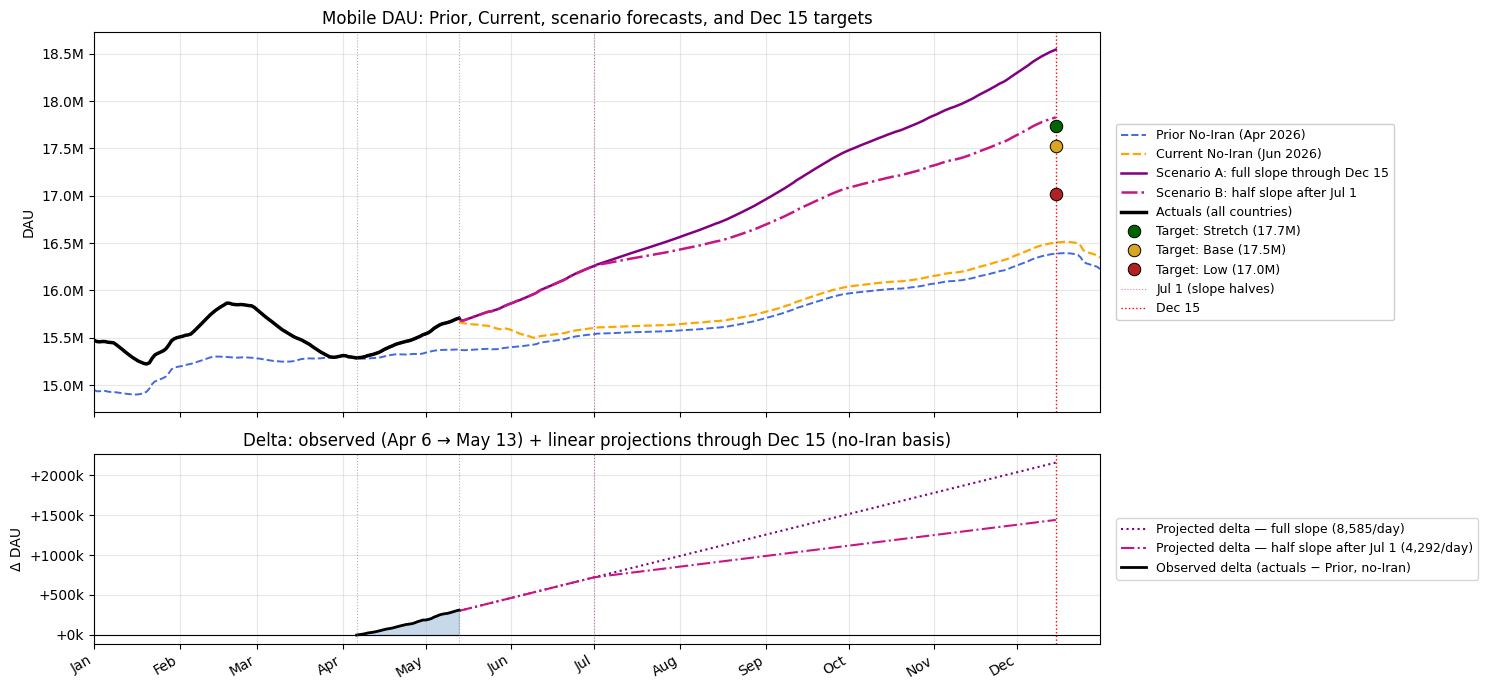

In [8]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 7), sharex=True,
                                gridspec_kw={"height_ratios": [2, 1]})

# Top
ax1.plot(df.index, df["april_no_iran"], color="royalblue", lw=1.4, ls="--",
         label="Prior No-Iran (Apr 2026)")
ax1.plot(df.index[current_mask], df.loc[current_mask, "june_draft_iran"],
         color="orange", lw=1.6, ls="--", label="Current No-Iran (Jun 2026)")
# Scenario forecasts
ax1.plot(proj.index, proj["scenario"], color="purple", lw=1.8,
         label="Scenario A: full slope through Dec 15")
ax1.plot(proj.index, proj["scenario_half"], color="mediumvioletred", lw=1.8, ls="-.",
         label="Scenario B: half slope after Jul 1")
ax1.plot(df.index, df["actuals_all"], color="black", lw=2.5,
         label="Actuals (all countries)")

# Dec 15 targets
TARGETS = {
    "Stretch (17.7M)": (17_742_615, "darkgreen"),
    "Base (17.5M)":    (17_522_795, "goldenrod"),
    "Low (17.0M)":     (17_019_424, "firebrick"),
}
for label, (value, color) in TARGETS.items():
    ax1.plot(PROJ_END, value, marker="o", color=color, markersize=9,
             markeredgecolor="black", markeredgewidth=0.7, linestyle="none",
             label=f"Target: {label}", zorder=5)

ax1.axvline(fit_start, color="gray", ls=":", lw=0.8, alpha=0.6)
ax1.axvline(fit_end, color="gray", ls=":", lw=0.8, alpha=0.6)
ax1.axvline(HALF_SLOPE_FROM, color="mediumvioletred", ls=":", lw=0.8, alpha=0.6,
            label="Jul 1 (slope halves)")
ax1.axvline(PROJ_END, color="red", ls=":", lw=1, label="Dec 15")
ax1.set_title("Mobile DAU: Prior, Current, scenario forecasts, and Dec 15 targets")
ax1.set_ylabel("DAU")
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))
ax1.legend(loc="center left", bbox_to_anchor=(1.01, 0.5), framealpha=0.95, fontsize=9)
ax1.grid(True, alpha=0.3)

# Bottom: observed delta + projected deltas
ax2.axhline(0, color="black", lw=0.8)
ax2.plot(proj.loc[fit_end:].index, proj.loc[fit_end:, "delta_proj"],
         color="purple", lw=1.5, ls=":",
         label=f"Projected delta — full slope ({slope:,.0f}/day)")
ax2.plot(proj.loc[fit_end:].index, proj.loc[fit_end:, "delta_proj_half"],
         color="mediumvioletred", lw=1.5, ls="-.",
         label=f"Projected delta — half slope after Jul 1 ({slope/2:,.0f}/day)")
ax2.plot(delta.index, delta["delta"], color="black", lw=2,
         label="Observed delta (actuals − Prior, no-Iran)")
ax2.fill_between(delta.index, 0, delta["delta"], color="steelblue", alpha=0.3)
ax2.axvline(fit_start, color="gray", ls=":", lw=0.8, alpha=0.6)
ax2.axvline(fit_end, color="gray", ls=":", lw=0.8, alpha=0.6)
ax2.axvline(HALF_SLOPE_FROM, color="mediumvioletred", ls=":", lw=0.8, alpha=0.6)
ax2.axvline(PROJ_END, color="red", ls=":", lw=1)
ax2.set_title("Delta: observed (Apr 6 → May 13) + linear projections through Dec 15 (no-Iran basis)")
ax2.set_ylabel("Δ DAU")
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e3:+.0f}k"))
ax2.xaxis.set_major_locator(mdates.MonthLocator())
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
ax2.legend(loc="center left", bbox_to_anchor=(1.01, 0.5), fontsize=9)
ax2.grid(True, alpha=0.3)
ax2.set_xlim(pd.Timestamp("2026-01-01"), pd.Timestamp("2026-12-31"))
plt.setp(ax2.get_xticklabels(), rotation=30, ha="right")
plt.tight_layout()
plt.show()